## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

- Toby Zhang: Data curation, Software
- Rohan Marda: Data curation, Software  
- Luke Huang: Writing – original draft
- Tyler Wong: Writing – original draft

# Research Question

**Can San Diego streets be grouped into distinct meaningful clusters based on their weekly citation volume and violation-type proportions in 2024, and do these clusters show significant differences in violation-type distributions and average fine amounts?**

## Background and Prior Work

Parking citations are a valuable lens through which to study urban enforcement dynamics, revenue generation, and spatial behavioral patterns. In cities, it has observed that citation volumes are unevenly distributed across streets and neighborhoods, and that both the types of violations and fine amounts can vary substantially. For example, in a study of parking tickets across 16 U.S. cities, Noli Brazil (2024) found that citation burdens are higher in neighborhoods with higher percentages of renters, younger adults, and Black residents <a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1). Such findings suggest that the data have structure beyond simple counts—there are meaningful differences by location, violation-type, and potentially enforcement practices. <a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2)

More specifically, research that uses clustering or unsupervised methods on parking or violation data points toward the possibility of grouping spatial units by their violation-profiles. For instance, SS Channamallu et al. (2025) applied a cluster-based analysis of parking satisfaction and strategies, identifying distinct user or location clusters based on violation type and parking conditions <a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3). Additionally, a study titled “Understanding Urban On-Street Parking Violations” analysed 10,396 violation records and examined temporal, spatial and violation-type determinants of those events (2019)<a name="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4). These studies provide methodological precedent for your proposed approach—grouping streets by characteristics of citation volume and violation-type proportions—and indicate that such clustering can reveal meaningful typologies of urban enforcement.

In light of this prior work, our research question—whether streets in San Diego can be grouped into meaningful clusters based on their weekly citation volume and violation-type proportions, and whether those clusters differ significantly in violation-type distributions and average fine amounts—is well grounded. The existence of spatial and typological variation in citation data is documented; clustering methods have been used successfully in related parking-violation contexts; and the differences in fine amounts and violation types across locations are also well established. What remains novel is applying these methods at the street level in San Diego, using weekly volumes and detailed violation-type proportions, and then testing for differences in average fines across clusters.

1. <a name="cite_note-1"></a> [^](#cite_ref-1) Brazil, N., Vang, B., & Abdelnur, H. (2024). **Neighborhood inequality in government fines: The case of parking tickets in 16 U.S. cities**. Cities, 152(103), 105229. https://www.sciencedirect.com/science/article/pii/S0264275124004438. Accessed 12 November 2025.
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Brazil, N. (2018). **The Unequal Spatial Distribution of City Government Fines: The Case of Parking Tickets in Los Angeles**. Urban Affairs Review. https://nbrazil.faculty.ucdavis.edu/wp-content/uploads/sites/481/2018/07/brazil_parking_tickets_uar_2018. Accessed 12 November 2025.
3. <a name="cite_note-3"></a> [^](#cite_ref-3) Channamallu, Sai Sneha, et al. **Cluster-Based Analysis of Parking Satisfaction and Strategies.** Transportation Research Procedia, vol. 90, 27 June 2025, pp. 790–797, www.sciencedirect.com/science/article/pii/S2352146525005885, https://doi.org/10.1016/j.trpro.2025.06.078. Accessed 12 November 2025.
4. <a name="cite_note-4"></a> [^](#cite_ref-4) Li, L., Gao, J., Liang, Y., Marks, D., Kang, J., & Li, Y. (2019). **Understanding Urban On-Street Parking Violations**. Transportation Research Record. https://journals.sagepub.com/doi/10.1177/03611981251378140. Accessed 12 November 2025.

# Hypothesis


**We hypothesize that streets will cluster into distinct low-, medium-, and high-volume citation groups, and that high-volume streets will have significantly different citation patterns - specifically, a higher proportion of meter-expiration, tow-away zone, and other high-turnover enforcement violations**

We expect this because high-traffic commercial areas typically experience more short-term parking turnover, stricter enforcement, and greater demand for curb space, which contributes to both higher citation volume and different mixes of violation types. Based on urban land-use and enforcement patterns, we anticipate these clusters will reveal meaningful structural differences between low-activity residential streets and high-pressure commercial corridors.

## Data

### Data overview

In [23]:
# Setup code -- Run only once after cloning!!! 
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('./modules')

import get_data
datafiles = [
    {'url': 'https://drive.google.com/uc?export=download&id=1zmubJLzsTN-_L2glokePj9YISZ5Ya94-', 'filename': 'parking_citations_2024_part1_datasd.csv'},
    {'url': 'https://drive.google.com/uc?export=download&id=1XOuzt5l4FegwjjcboIvjuHPwrSdsZ1Xk', 'filename': 'parking_citations_2024_part2_datasd.csv'}
]

get_data.get_raw(datafiles, destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:05<00:05,  5.23s/it]

Successfully downloaded: parking_citations_2024_part1_datasd.csv


Overall Download Progress: 100%|██████████| 2/2 [00:16<00:00,  8.45s/it]

Successfully downloaded: parking_citations_2024_part2_datasd.csv


### Dataset Name: Parking Citations San Diego 2024
  - Link to the dataset: [https://data.sandiego.gov/datasets/parking-citations/](https://data.sandiego.gov/datasets/parking-citations/)

  - Number of observations: 475,638

  - Number of variables: 8
    - ```citation_id```: Unique citation identifier.
    - ```date_issue```: Date citation was issued.
    - ```date_creation```: Date citation was created. This refers to when the citation was entered into the database.
    - ```location```: Street number and name of where the citation was issued. (eg. 1400 Market St)
    - ```sector1```: The sector of Parking Enforcement issuing the citation. (eg. CSD(I) Parking Enf)
    - ```vio_code```: The section of the law violated. (eg. 86.0124 SDMC)
    - ```vio_desc```: A description of the violation. (eg. Expired meter)
    - ```vio_fine```: The fine assessed at the time of citation in USD ($). (eg. 52.5)

  - The dataset is publicly available under California transparency laws and maintained by the City of San Diego's Performance and Analytics Department (PandA), and thus can be generally considered reliable, but it may contain errors or inconsistencies common in administrative data. One noteworthy shortcoming is the lack of a time of cite, which would have allowed finer grained time-series analysis. The data also may have slight inconsistencies and biases as the data is collected from several agencies (Parking Enforcement, Street Sweepers, Police Officers, etc.), each of which may have differing operating procuedures. Furthermore, officers may unconciously target certain areas (eg. Downtown) and cars (eg. classic or luxury vehicles) more often, which could cause an overrepresentation of those groups in our dataset.

###### Note: Although we are using a single dataset, the data provider split it into two separate files. We imported both files, concatenated them, and will treat them as a single dataset for all analyses. 

In [21]:
# load data and concatenate
part1 = pd.read_csv('data/00-raw/parking_citations_2024_part1_datasd.csv')
part2 = pd.read_csv('data/00-raw/parking_citations_2024_part2_datasd.csv')
df = pd.concat([part1, part2], axis=0)

df.info()

C:\Users\rohan\AppData\Local\Temp\ipykernel_16028\3055169173.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  part1 = pd.read_csv('data/00-raw/parking_citations_2024_part1_datasd.csv')
C:\Users\rohan\AppData\Local\Temp\ipykernel_16028\3055169173.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  part2 = pd.read_csv('data/00-raw/parking_citations_2024_part2_datasd.csv')


<class 'pandas.core.frame.DataFrame'>
Index: 475638 entries, 0 to 248256
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   citation_id    475638 non-null  object 
 1   date_issue     475638 non-null  object 
 2   date_creation  475638 non-null  object 
 3   location       475563 non-null  object 
 4   sector1        475638 non-null  object 
 5   vio_code       475638 non-null  object 
 6   vio_desc       475638 non-null  object 
 7   vio_fine       475638 non-null  float64
dtypes: float64(1), object(7)
memory usage: 32.7+ MB


In [22]:
df.head()

,citation_id,date_issue,date_creation,location,sector1,vio_code,vio_desc,vio_fine
0,101637347,2024-01-01,2024-02-01,3600 CALIFORNIA STREET,CSD (S) POLICE,5204(A) CVC,CURRENT REGISTRATION NOT DISPLAYED,37.5
1,101660865,2024-01-01,2024-01-21,1500 C ST,CSD (S) POLICE,5204(A) CVC,CURRENT REGISTRATION NOT DISPLAYED,37.5
2,101660866,2024-01-01,2024-01-21,1400 B ST,CSD (S) POLICE,5204(A) CVC,CURRENT REGISTRATION NOT DISPLAYED,37.5
3,101496678,2024-01-01,2024-01-23,300 5TH AVENUE,CSD (S) POLICE,86.0112(E)SD MC,VIOLATION OF SIGNS (SDMC),52.5
4,59899217,2024-01-01,2024-01-02,MARINERS POINT LOT 3200 MARINERS WAY,CSD (S) POLICE,86.0112(E)SD MC,VIOLATION OF SIGNS (SDMC),52.5


The most pertinent variables that we will consider are ```location```, ```vio_desc```, and ```vio_fine```.
- ```location```: This is the primary unit for aggregation and clustering in this project. Standardization is necessary because abbreviations and inconsistencies (e.g., “St” vs “St.” or “Ave” vs “Ave.”) exist.
- ```vio_desc```: Each description is accompanied by the respective section of the California Vehicle Code (CVC), San Diego Municipal Code (SDMC), or other relevant law in ```vio_code```. Would be used to further understand how violation types vary by location.
- ```vio_fine```: Fines vary by violation type and location, and we wish to further study how variations in location and violation affect fines.

The data is already tidy. There is a row for each observation (```citation_id```), and each observation has a column for a variable (```date_issue```, ```location```, ```vio_fine```, etc.). The data follows a consistent layout that is suitable for analysis.

In [4]:
# check missingness, if any
df[df.isna().any(axis=1)]

,citation_id,date_issue,date_creation,location,sector1,vio_code,vio_desc,vio_fine
2348,59899306,2024-01-03,2024-01-03,NaN,CSD (S) POLICE,22507.8(a)CVC,DISABLED PARKING,0.0
3465,101709578,2024-01-04,2024-01-21,NaN,CSD (S) POLICE,4000(A)1 CVC,EXPIRED REGISTRATION,52.5
17623,59944425,2024-01-13,2024-01-13,NaN,CSD (I) PARKING ENF,86.0126 SDMC,EXPIRED METER,42.5
17626,59944424,2024-01-13,2024-01-13,NaN,CSD (I) PARKING ENF,86.0126 SDMC,EXPIRED METER,42.5
21386,101709841,2024-01-17,2024-02-01,NaN,CSD (S) POLICE,4000(A)1 CVC,EXPIRED REGISTRATION,52.5
...,...,...,...,...,...,...,...,...
195260,101709147,2024-11-16,2025-04-04,NaN,CSD (S) POLICE,4000(A)1 CVC,EXPIRED REGISTRATION,52.5
211376,61164247,2024-11-30,2024-11-30,NaN,CSD (I) PARKING ENF,22514 CVC,FIRE HYDRANT,77.5
231488,101699632,2024-12-15,2025-01-16,NaN,CSD (S) POLICE,86.0112(F) SDMC,RED ZONE,77.5
239962,101650345,2024-12-22,2025-02-10,NaN,CSD (I) PARKING ENF,22500(C) CVC,"SIGNS, RED ZONES",52.5


75 citations are missing ```location``` data. This could be because the citations were issued on unnamed roads, or the issuing officer did not know the location. Since there is no correlation between these missing location data and other variables, we can conlude there is no systemic bias explaining the missingness. Moreever, due to the extremely low proportion of missing citations (75 out of 475,638), we chose to drop these observations from our dataset as they would not influence our analysis.

In [16]:
df = df.dropna(how='any')
print('Updated shape:', df.shape)

Updated shape: (475563, 8)


The location data available in the dataset is extremely fine grained, providing specific street numbers. Moreover, street names are not consistently stored, evidenced by multiple abbreviations for the same word (eg. 'ave' and 'av' for 'avenue'). We utilized a large dictionary of common street abbreviations to strandardize location names and stripped street numbers to allow for generalization.

Lastly, we dropped ```date_creation``` as it provided redudant and irrelevant information. ```date_issue``` provides the true date of the citation.

In [17]:
# number of unqiue locations before cleaning
print('(Before clean) No. unique locations', df['location'].value_counts().shape[0])

# removing street numbers
cleaned_df = df.copy()
cleaned_df['location'] = cleaned_df['location'].apply(lambda x: ' '.join(x.split(' ')[1:]).strip() if x.split(' ')[0].isnumeric() else x)
cleaned_df['location'].value_counts()

# standardize names
def clean_location(location):
    street_standardization = {
    'street':'st','st.':'st','avenue':'ave','ave.':'ave','av':'ave','av.':'ave',
    'boulevard':'blvd','blvd.':'blvd','road':'rd','rd.':'rd','drive':'dr','dr.':'dr',
    'lane':'ln','ln.':'ln','court':'ct','ct.':'ct','place':'pl','pl.':'pl','circle':'cir',
    'cir.':'cir','terrace':'ter','ter.':'ter','parkway':'pkwy','pkwy.':'pkwy','way':'way',
    'wy.':'way','highway':'hwy','driveway':'drwy','plaza':'plz','plz.':'plz',
    'center':'ctr','centre':'ctr','ctr.':'ctr','heights':'hts','trail':'trl','loop':'loop',
    'vista':'vsta','hill':'hl','hills':'hls','ridge':'rdg','valley':'vly','grove':'grv',
    'mount':'mt','mountain':'mtn','creek':'crk','harbor':'hbr','harbour':'hbr','point':'pt',
    'landing':'lndg','meadow':'mdw','meadows':'mdws','bay':'bay','shore':'shr','shores':'shrs',
    'park':'park','orchard':'orch','northeast':'ne','ne.':'ne','northwest':'nw','southeast':'se',
    'southwest':'sw','sw.':'sw','first':'1st','second':'2nd','third':'3rd','fourth':'4th',
    'fifth':'5th','sixth':'6th','seventh':'7th','eighth':'8th','ninth':'9th','tenth':'10th',
    'eleventh':'11th','twelfth':'12th','thirteenth':'13th','fourteenth':'14th','fifteenth':'15th',
    'sixteenth':'16th','seventeenth':'17th','eighteenth':'18th','nineteenth':'19th','twentieth':'20th',
    'avenue.':'ave','street.':'st'
    }
    
    tokens = location.lower().split()
    cleaned = [street_standardization.get(tok, tok) for tok in tokens]
    
    return ' '.join(cleaned)

cleaned_df['location'] = cleaned_df['location'].apply(clean_location)
print('(After clean) No. unique locations', cleaned_df['location'].value_counts().shape[0])

# Drop redundant 'date_creation' column
cleaned_df = cleaned_df.drop(columns=['date_creation'])

# converting dates to Timestamp objects for analysis
cleaned_df['date_issue'] = pd.to_datetime(cleaned_df['date_issue'])

cleaned_df.sample(5)

(Before clean) No. unique locations 113188
(After clean) No. unique locations 18447


,citation_id,date_issue,location,sector1,vio_code,vio_desc,vio_fine
125833,61167930,2024-09-27,s 39th st,CSD (I) PARKING ENF,86.0137(D) SDMC,RENT/LEASE/SALE VEHICLE ON STREET,77.5
71471,101680414,2024-08-18,37th st,CSD (S) POLICE,22514 CVC,FIRE HYDRANT,77.5
169722,61217038,2024-10-28,currant st,CSD (I) PARKING ENF,22500(E) CVC,DRIVEWAY,57.5
116541,60047182,2024-04-06,hewlett dr,CSD (I) PARKING ENF,86.0111 SDMC,WHEEL CRAMPING-HILL,59.5
233876,61278617,2024-12-17,garnet ave,CSD (I) PARKING ENF,22507.8(a)CVC,DISABLED PARKING,0.0


Summary statistics of key variables:

- ```date_issue```

<Axes: title={'center': 'Number of Citations per Month'}, xlabel='Month', ylabel='Number of Citation'>

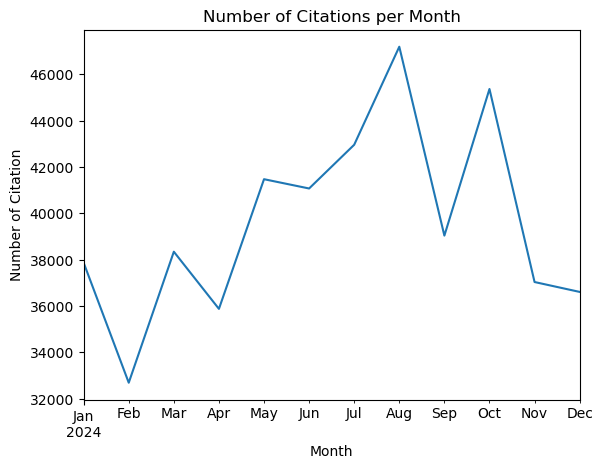

In [7]:
# Line graph of number citations per month
cites_by_month = cleaned_df.groupby(cleaned_df['date_issue'].dt.to_period('M')).count()['citation_id']
cites_by_month.plot(
    kind='line',
    title='Number of Citations per Month',
    xlabel='Month',
    ylabel='Number of Citation')

The line plot of citations does not contain any obvious outliers, and provides some insight into citations numbers over the year.

- ```vio_desc```

In [ ]:
vio_types = cleaned_df['vio_desc'].value_counts()
vio_types

<Axes: title={'center': 'Violation Types'}, xlabel='Count', ylabel='Violation Description'>

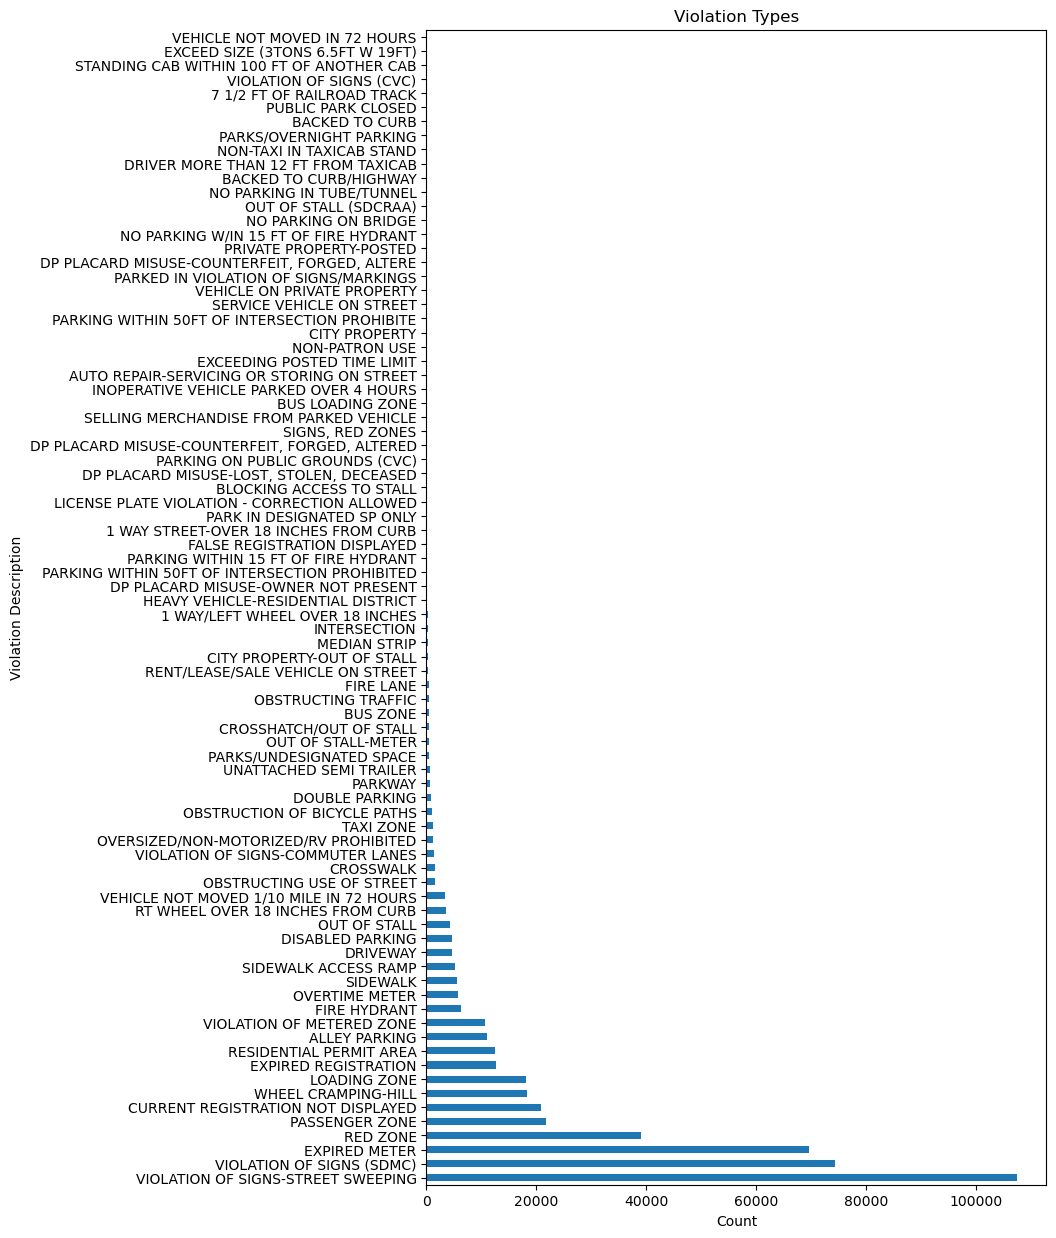

In [ ]:
# Bar plot of violation types
plt.figure(figsize=(8, 15))
vio_types.plot(kind='barh', x='count', title='Violation Types', xlabel='Count', ylabel='Violation Description')

Though there are many different types of violations, only a few are relatively common, with the majority of violations having little to no representation. We chose to focus on these common violations as they are the most repeatedly violated by filtering out those violation groups with less than 4000 citations.

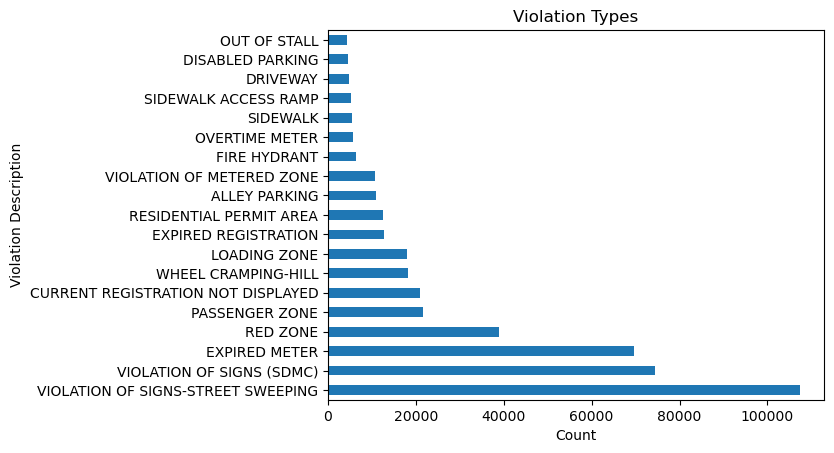

Updated shape: (452702, 7)


In [26]:
# filter out violations with less than 5000 citations
processed_df = cleaned_df.groupby('vio_desc').filter(lambda x: len(x) >= 4000)
vio_types = processed_df['vio_desc'].value_counts()
vio_types.plot(kind='barh', x='count', title='Violation Types', xlabel='Count', ylabel='Violation Description')
plt.show()
print('Updated shape:', processed_df.shape)

- ```vio_fine```

In [25]:
processed_df['vio_fine'].describe()

count    452702.000000
mean         59.150692
std          45.241062
min           0.000000
25%          52.500000
50%          52.500000
75%          52.500000
max         452.500000
Name: vio_fine, dtype: float64

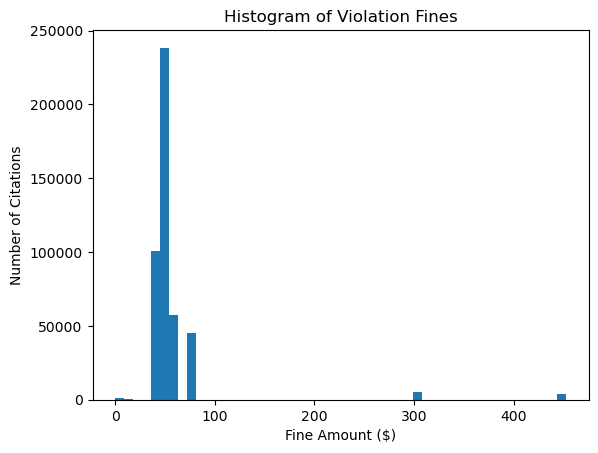

In [10]:
# Histogram of violation fines
fines = processed_df['vio_fine'].plot(kind='hist', bins=50, title='Histogram of Violation Fines', xlabel='Fine Amount ($)', ylabel='Number of Citations')

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [13]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [14]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics

Instructions: Keep the contents of this cell. For each item on the checklist
-  put an X there if you've considered the item
-  IF THE ITEM IS RELEVANT place a short paragraph after the checklist item discussing the issue.
  
Items on this checklist are meant to provoke discussion among good-faith actors who take their ethical responsibilities seriously. Your teams will document these discussions and decisions for posterity using this section.  You don't have to solve these problems, you just have to acknowledge any potential harm no matter how unlikely.

Here is a [list of real world examples](https://deon.drivendata.org/examples/) for each item in the checklist that can refer to.

[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> Our project uses parking citation data that does not identify individual people or vehicles. The data represents overall  patterns and trends in citations rather than tracking specific individuals, so informed consent is not applicable to our analysis.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> Potential biases include possible overrepresentation of certain vehicle types and areas, due to differences in officer procedures, as well as temporary factors like construction and special event parking. Data will be aggregated over the full year to smooth and average fluctuations.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

> Our data consists of citation numbers and details, and does not identify any vehicles or persons. Thus, structures to minimize personally identifiable information (PII) are not relevant to this project.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

> While our parking citation dataset does not include individual-level demographic information, we will consider potential inequitable impacts of our findings. We will flag clusters that are associated with higher average fines or a higher proportion of certain violation types and examine whether these clusters disproportionately occur in neighborhoods with specific income levels, racial/ethnic compositions, or other socioeconomic characteristics.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
 > Data will be stored on UCSD servers, which is encrypted by Duo.
 - [ ] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?
 > Data will be slated for deletion if not used for more than 2 years.

### C. Analysis
 - [ ] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

> Due to differences in socioeconomic conditions, parking density, and enforcement practices, certain neighborhoods may receive disproportionately more citations than others. To mitigate this, we will use robust standard errors to reduce the influence of localized enforcement intensity.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

> We will clearly indicate confidence intervals, sample sizes, and limitations in our visualizations. We'll avoid cherry-picking favorable results and will present both significant and non-significant findings, along with their practical and statistical significance.

 - [ ] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

> All the code used for analyses will be publically available with clear step-by-step explainations. We will make use of file versioning to revert to stable versions, should issues with developing version arise.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
 > In the process of our analysis, if we were to find features that could serve as proxies for socioeconomic status or enforcement bias, we would analyse their impact further and decide whether they should be excluded from our study.

 - [ ] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [ ] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
 - [ ] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

> The clustering analysis should be represented as a descriptive and exploratory study, not as a guide for enforcement or policy action. The identified street clusters represent statistical groupings based on citation patterns, specifically, weekly citation volume, violation-type proportions, and average fine amounts. They do not establish any relationships nor indicate intent for enforcement agencies. 

### E. Deployment
 - [ ] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?

 > We will preserve old cluster models and datasets and ensure reproducability in our code to allow for a rollback to earlier analyses for comparison.

 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?
 > This analysis is conducted exclusively for research purposes and is not designed for, nor should it be applied to, targeted enforcement or punitive actions. We will make this clear in documentation accompanying our project.

## Team Expectations 

* All 4 team members are expected to contribute equally to all parts of the project.
* The primary mode of communication is through iMessage and email. Team members are expected to respond to messages as soon as possible, and within 48 hours at the latest.
* All members are expected to attend weekly team meetings, held typically on Saturday evenings, to discuss progress, issues, and plan next steps. If a member is unable to attend this meeting, they should inform the group at the earliest.
* Team members are expected to be courteous and respect one another. This includes giving constructive criticism politely and being open minded while receiving feedback.
* Workload will be split according to preferences and team member strengths, but members are expected to review and contribute feedback to all sections of the project.
* Team members are expected to communicate early if they encounter difficulties. If a member fails to contribute adequately or communicate delays, the team will attempt to conduct a meeting to resolve the issue. If unsuccessful, the team will document the issue and notify the instructor.
* All team members have contributed, acknowledged, and agreed to all of the expectations (including the COGS108 Team Policy) stated above.

## Project Timeline Proposal

**Project Timeline:**

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| Nov 1 (Saturday)  |  7 PM | Review existing parking and weather datasets; Begin initial data exploration | Finalize data cleaning strategy; Assign data processing responsibilities; Set up team communication protocols | 
| Nov 8 (Saturday)  |  7 PM | Complete data cleaning and preprocessing; Map parking structures to neighborhoods | Review cleaned datasets; Discuss data wrangling approach; Plan neighborhood mapping strategy | 
| **Nov 12**  | **Due Date** | **Complete Checkpoint #1: Data** - Clean datasets, setup code, document data sources | **Submit Checkpoint #1** - Dataset descriptions, data cleaning documentation, setup packages |
| Nov 15 (Saturday)  | 7 PM  | Begin EDA on weather patterns and parking trends; Create initial visualizations | Review data distributions; Identify outliers; Plan relationship analysis between variables |
| Nov 22 (Saturday)  | 7 PM  | Complete variable distribution analysis; Generate correlation visualizations | Review EDA findings; Discuss statistical analysis approaches; Refine visualizations |
| **Nov 26**  | **Due Date** | **Complete Checkpoint #2: EDA** - Finalize exploratory analysis with interpretations | **Submit Checkpoint #2** - EDA with distributions, outliers, variable relationships |
| Nov 29 (Saturday)  | 7 PM  | Begin correlation analysis and regression modeling; Apply machine learning techniques | Review statistical results; Discuss model performance; Plan final analysis approach |
| Dec 6 (Saturday)  | 7 PM  | Complete predictive modeling; Draft results and conclusion sections | Review model findings; Discuss limitations; Assign final report sections and video tasks |
| **Dec 10**  | **Finals Due** | **Complete Final Project** - Finalize report, create 3-5 minute video, submit team evaluations | **Submit Final Project** - Complete notebook, video submission, team surveys |

**Key Deliverables by Checkpoint:**
- **Nov 12 - Checkpoint #1: Data**: Clean datasets (parking occupancy + weather), setup packages, document data sources (~1000+ observations), data cleaning documentation with preprocessing steps
- **Nov 26 - Checkpoint #2: EDA**: Complete exploratory data analysis with variable distributions, outlier identification, relationship analysis between weather and parking variables, appropriate visualizations with interpretations
- **Dec 10 - Final Project**: Complete analysis with correlation/regression modeling, predictive ML techniques, final report with 3+ visualizations, ethics/privacy considerations, conclusion/discussion, 3-5 minute video presentationInstructions: Replace this with your timeline.